In [48]:
import os
import numpy as np
from PIL import Image
from typing import List, Tuple, Optional, Union
import matplotlib.pyplot as plt


def _np_dtype_from_nrrd_type(nrrd_type: str) -> np.dtype:
    """
    Map NRRD 'type' strings to NumPy dtypes.
    """
    mapping = {
        'uchar': np.uint8,
        'uint8': np.uint8,
        'short': np.int16,
        'ushort': np.uint16,
        'int': np.int32,
        'uint': np.uint32,
        'float': np.float32,
        'double': np.float64,
    }
    try:
        return mapping[nrrd_type]
    except KeyError:
        raise ValueError(f"Unsupported NRRD data type: {nrrd_type}")


class NRRDLoader:
    """
    Class for loading NRRD (.nhdr + .raw) volumetric data,
    extracting 2D slices, converting to images, and sampling random crops.
    """
    def __init__(self, header_path: str) -> None:
        """
        Initialize with path to the NRRD header (.nhdr) file.
        The .raw file must be in the same directory with the name specified in the header.
        """
        self.header_path: str = header_path
        self.header: dict = {}
        self.sizes: Tuple[int, int, int]
        self.type: str
        self.endian: str
        self.encoding: str
        self.data_file: str
        self.data: Optional[np.ndarray] = None
        self._parse_header()

    def _parse_header(self) -> None:
        """
        Read the header file and parse key/value pairs into self.header.
        """
        with open(self.header_path, 'r') as f:
            for line in f:
                line: str = line.strip()
                if not line or line.startswith(('#', "NRRD")):
                    continue
                key, val = line.split(':', 1)
                self.header[key.strip()] = val.strip().strip('"')

        # Required fields
        self.sizes = tuple(map(int, self.header['sizes'].split()))  # (X, Y, Z)
        self.type = self.header['type']
        self.endian = self.header.get('endian', 'little')
        self.encoding = self.header.get('encoding', 'raw')
        raw_name = self.header.get('data file', '')
        self.data_file = os.path.join(os.path.dirname(self.header_path), raw_name)

    def load_volume(self) -> np.ndarray:
        """
        Load the volumetric data into a NumPy array of shape (Z, Y, X).

        Returns:
            3D NumPy array of shape (Z, Y, X).
        """
        dtype = _np_dtype_from_nrrd_type(self.type)
        total_elems = int(np.prod(self.sizes))

        with open(self.data_file, 'rb') as f:
            flat = np.fromfile(f, dtype=dtype, count=total_elems)

        # NRRD sizes are given as X Y Z; reshape to (Z, Y, X)
        volume = flat.reshape(self.sizes[::-1]).transpose(0, 1, 2)
        self.data = volume
        return volume

    def get_slices(self, axis: int = 0) -> List[np.ndarray]:
        """
        Return a list of 2D slices along the given axis (0=Z, 1=Y, 2=X).

        Args:
            axis: Axis to slice along.
        Returns:
            List of 2D NumPy arrays.
        """
        if self.data is None:
            self.load_volume()
        assert self.data is not None
        return [np.take(self.data, i, axis=axis) for i in range(self.data.shape[axis])]

    def slice_to_image(self, slice_array: np.ndarray) -> Image.Image:
        """
        Convert a 2D NumPy array slice to a PIL Image (grayscale).
        Performs normalization to [0, 255].
        """
        arr = slice_array.astype(np.float32)
        arr -= arr.min()
        arr /= (arr.ptp() + 1e-8)
        arr *= 255.0
        img = Image.fromarray(arr.astype(np.uint8), mode='L')
        return img

    def save_slices(self, out_dir: str, axis: int = 0, prefix: str = 'slice') -> List[np.ndarray]:
        """
        Save all slices along an axis to PNG files in out_dir.

        Args:
            out_dir: Directory to save PNGs.
            axis: Axis to slice along.
            prefix: Filename prefix.
        """
        os.makedirs(out_dir, exist_ok=True)
        for idx, sl in enumerate(self.get_slices(axis=axis)):
            img = self.slice_to_image(sl)
            path = os.path.join(out_dir, f"{prefix}_{idx:04d}.png")
            img.save(path)
            
        return self.get_slices(axis=axis)

    def sample_crops(
        self,
        num_crops: int = 7500,
        crop_size: int = 64,
        axis: int = 0
    ) -> List[Image.Image]:
        """
        Randomly sample crops of size (crop_size, crop_size) from volume slices.

        Args:
            num_crops: Number of random crops.
            crop_size: Height and width of each crop.
            axis: Axis to sample slices along.

        Returns:
            List of PIL Images of cropped patches.
        """
        if self.data is None:
            self.load_volume()
        assert self.data is not None

        Z, H, W = self.data.shape
        crops: List[Image.Image] = []
        rng = np.random.default_rng()

        for _ in range(num_crops):
            z = int(rng.integers(0, Z)) if axis == 0 else None
            y = int(rng.integers(0, H - crop_size + 1)) if axis in (0, 1) else None
            x = int(rng.integers(0, W - crop_size + 1)) if axis in (0, 2) else None

            if axis == 0:
                patch = self.data[z, y:y+crop_size, x:x+crop_size]
            elif axis == 1:
                patch = self.data[y, z:z+crop_size, x:x+crop_size]
            else:
                patch = self.data[y:y+crop_size, x:x+crop_size, z]

            crops.append(self.slice_to_image(patch))

        return crops
    
    def plot_slice(
        self,
        slice_data: Union[np.ndarray, Image.Image],
        title: Optional[str] = None,
        cmap='twilight'
    ) -> None:
        """
        Plot a 2D slice or PIL image using matplotlib.

        Args:
            slice_data: Either a 2D NumPy array or a PIL Image.
            title: Optional title for the plot.
        """
        if isinstance(slice_data, Image.Image):
            arr = np.array(slice_data)
        else:
            arr = slice_data
        fig, ax = plt.subplots()
        ax.imshow(arr,) #cmap=cmap)
        ax.axis('off')
        if title:
            ax.set_title(title)
        plt.show()
        
#     def plot(
#         self,
#         imgs: Union[List[Union[np.ndarray, Image.Image] ] ],
#         titles: List[str] = None
#     ):
#         if not titles:
#             titles = [None] * len(imgs)
            
#         for image, title in zip(imgs, titles):
#             self.plot_slice(image, title)
            

# Example usage:
# loader = NRRDLoader('A1.nhdr')
# volume = loader.load_volume()
# loader.save_slices('slices/', axis=0)
# crops = loader.sample_crops(num_crops=7500, crop_size=64)


In [49]:
from pathlib import Path

filename = "A1"
dataset_path = Path(r"C:\TopoGAN-ECCV2020\Data\rock")
nhdr_file = dataset_path / "data" / f"{filename}.nhdr"
slices_path = dataset_path / "slices"

loader = NRRDLoader(nhdr_file)
volume = loader.load_volume()
slices = loader.save_slices(slices_path, axis=0)
crops = loader.sample_crops(num_crops=5, crop_size=64)


In [50]:
crops

[<PIL.Image.Image image mode=L size=64x64>,
 <PIL.Image.Image image mode=L size=64x64>,
 <PIL.Image.Image image mode=L size=64x64>,
 <PIL.Image.Image image mode=L size=64x64>,
 <PIL.Image.Image image mode=L size=64x64>]

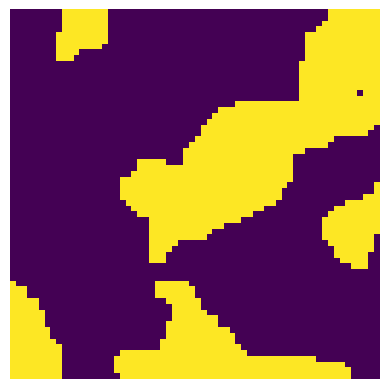

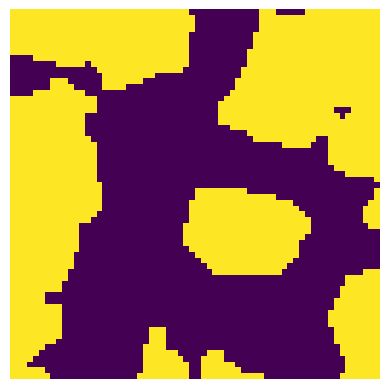

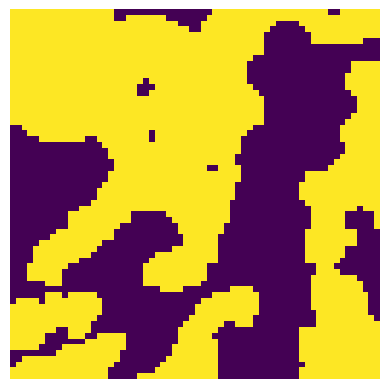

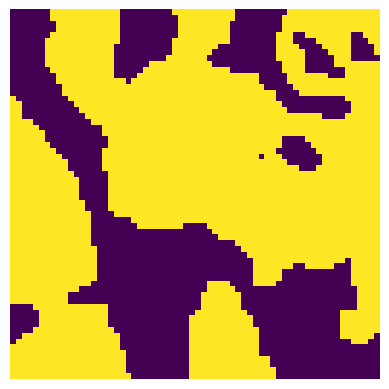

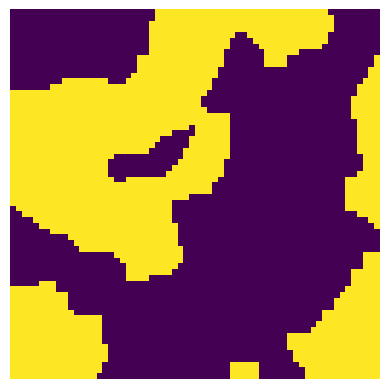

In [51]:
loader.plot(crops)

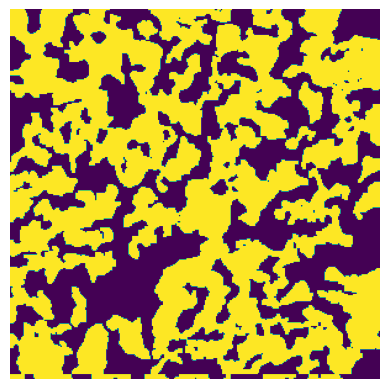

(None, 300)

In [47]:
loader.plot_slice(slices[0]), len(slices)

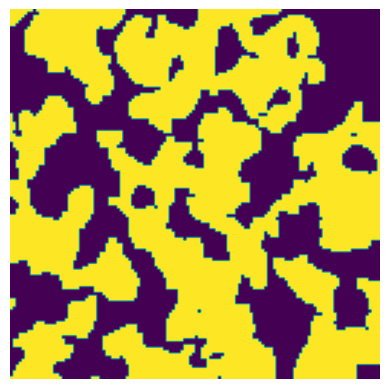

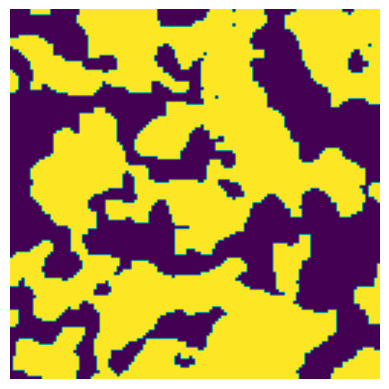

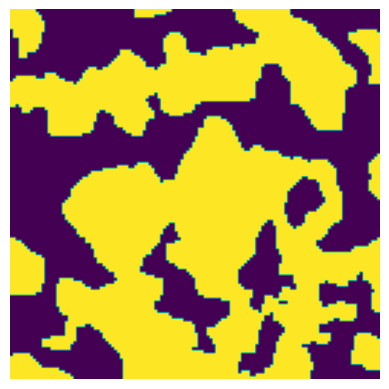

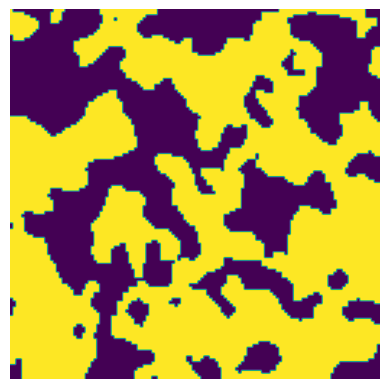

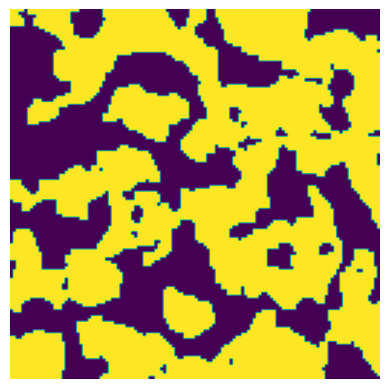

In [52]:
crops_128 = loader.sample_crops(num_crops=5, crop_size=128)
loader.plot(crops_128)